In [21]:
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import textwrap
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [22]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
ending_date = input_data["simulation_timeframe"]["ending_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Ending date: {ending_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")


print(country_code)

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print(data_path)
print(output_path)
print(analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Ending date: 2024/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555
ng-se
DATA
validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/output
validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/analysis


## Population

## <span style="color:red"> DO NOT USE CALIBRATION YEAR HERE, USE INCIDENCE DATA </span>

In [23]:
incidence_calibration_start_date = f'{incidence_comparison_year}-01-01'
incidence_calibration_end_date = f'{incidence_comparison_year + 1}-01-01'   # Calibrate from Jan 1 of the comparison year to end of that year (Jan 1 of the next year)
print(f"Calibration period: {incidence_calibration_start_date} to {incidence_calibration_end_date}")

Calibration period: 2021-01-01 to 2022-01-01


In [24]:
output_1_db = output_path / "validation_monthly_data_13.db"
print(f"Reading monthly data from: {output_1_db}")
# date = get_table_with_columns(output_1_db, ["*"], "monthly_data")
date = get_table(output_1_db, "monthly_data")
# Load yaml input file
date['date'] = pd.to_datetime(starting_date) + pd.to_timedelta(date['days_elapsed'], unit='D')
date = date.rename(columns={"id": "monthly_data_id"})
date = date.sort_values("date")
date_dict = date.set_index("monthly_data_id")["date"].to_dict()

Reading monthly data from: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/output/validation_monthly_data_13.db


In [25]:
print(f"Date dict info:")
print(f"  Number of entries: {len(date_dict)}")
print(f"  First entry: {list(date_dict.items())[0]}")
print(f"  Last entry: {list(date_dict.items())[-1]}")

Date dict info:
  Number of entries: 157
  First entry: (1, Timestamp('2011-01-01 00:00:00'))
  Last entry: (157, Timestamp('2024-01-01 00:00:00'))


In [26]:
agg_population_data = pd.read_csv(analysis_path / "agg_population_pixel.csv")
agg_population_data["date"] = agg_population_data["monthly_data_id"].map(date_dict)
agg_population_data

,monthly_data_id,location_id,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,population_20,date
0,1,0,305,305,305,305,305,305,305,305,...,305,305,305,305,305,306,305,305,305,2011-01-01
1,1,1,586,586,586,586,586,586,586,586,...,586,586,586,586,586,586,586,586,586,2011-01-01
2,1,2,323,323,323,323,323,323,323,323,...,323,323,323,323,323,323,323,323,323,2011-01-01
3,1,3,135,135,135,135,135,135,135,135,...,135,135,135,135,135,135,135,135,135,2011-01-01
4,1,4,555,555,555,555,555,555,555,555,...,555,555,555,555,555,555,556,555,555,2011-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075602,157,6846,1232,1234,1188,1185,1197,1182,1183,1181,...,1164,1193,1236,1177,1148,1172,1170,1213,1204,2024-01-01
1075603,157,6847,1955,2001,1924,1881,1919,1928,1987,1948,...,1901,1954,1983,1929,1903,1973,1906,1927,1939,2024-01-01
1075604,157,6848,3249,3323,3243,3364,3324,3306,3252,3272,...,3344,3287,3340,3355,3336,3356,3261,3258,3290,2024-01-01
1075605,157,6849,828,854,783,850,844,846,862,882,...,849,839,825,839,830,846,865,837,834,2024-01-01


In [27]:
# 1. See the actual spread of dates being mapped
# print(sorted(date_dict.items()))

# 2. Confirm dtype and values of the calibration window
print("calibration_start_date:", incidence_calibration_start_date, type(incidence_calibration_start_date))
print("calibration_end_date:", incidence_calibration_end_date, type(incidence_calibration_end_date))

# 3. Confirm dtype of the date column itself
print("Date column dtype:", agg_population_data["date"].dtype)
print("Date column range:", agg_population_data["date"].min(), "-", agg_population_data["date"].max())

# 4. Check how many unique dates exist in the full range
# print(agg_population_data["date"].nunique())
# print(sorted(agg_population_data["date"].unique()))

calibration_start_date: 2021-01-01 <class 'str'>
calibration_end_date: 2022-01-01 <class 'str'>
Date column dtype: datetime64[us]
Date column range: 2011-01-01 00:00:00 - 2024-01-01 00:00:00


In [28]:
mask = (agg_population_data["date"] >= incidence_calibration_start_date) & (agg_population_data["date"] <= incidence_calibration_end_date)
print("Number of True values in mask:", mask.sum())

agg_population_data_at_calibration = agg_population_data.loc[(agg_population_data["date"] >= incidence_calibration_start_date) & (agg_population_data["date"] <= incidence_calibration_end_date), :].reset_index(drop=True)
columns_to_drop = ["monthly_data_id","location_id", "date"]
agg_population_data_at_calibration["mean"] = agg_population_data_at_calibration.drop(columns=columns_to_drop).mean(axis=1)
agg_population_data_at_calibration

Number of True values in mask: 89063


,monthly_data_id,location_id,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_13,population_14,population_15,population_16,population_17,population_18,population_19,population_20,date,mean
0,121,0,353,372,332,348,339,372,354,348,...,345,353,369,354,383,360,373,355,2021-01-01,357.30
1,121,1,699,679,638,674,671,672,681,669,...,667,655,675,663,710,679,671,646,2021-01-01,671.85
2,121,2,370,374,390,404,404,377,356,416,...,365,370,398,395,388,386,417,390,2021-01-01,386.40
3,121,3,165,161,143,149,171,157,143,143,...,157,155,149,159,163,154,148,164,2021-01-01,156.10
4,121,4,612,617,665,677,672,658,671,638,...,641,652,682,641,652,652,667,676,2021-01-01,658.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89058,133,6846,1186,1174,1140,1118,1180,1157,1128,1158,...,1177,1172,1133,1146,1116,1131,1155,1148,2022-01-01,1150.15
89059,133,6847,1912,1937,1890,1813,1846,1879,1925,1881,...,1892,1910,1871,1847,1898,1853,1857,1869,2022-01-01,1882.20
89060,133,6848,3174,3232,3145,3287,3165,3230,3151,3227,...,3154,3251,3245,3222,3222,3147,3157,3213,2022-01-01,3201.70
89061,133,6849,789,826,775,810,825,834,835,836,...,812,802,812,818,797,828,820,796,2022-01-01,815.40


In [29]:
pop_cols = [f"population_{i}" for i in range(1, 16)]

agg_population_totals_by_bucket = (
    agg_population_data_at_calibration
    .groupby("date")[pop_cols]   # sum over all location_ids per date
    .sum()
    .mean()                      # mean across dates
    / population_scale_from_input_yml
)

# print("Total population from mean of sims (per population bucket):")
# print(agg_population_totals_by_bucket)

agg_population_totals_by_bucket_df = (
    agg_population_totals_by_bucket
    .rename("total_population")
    .rename_axis("population_bucket")
    .reset_index()
)

agg_population_totals_by_bucket_df["total_population"] = agg_population_totals_by_bucket_df["total_population"].apply(lambda x: f"{x:,.0f}")

agg_population_totals_by_bucket_df

# print(agg_population_totals_by_bucket_df)


,population_bucket,total_population
0,population_1,"25,017,185"
1,population_2,"25,006,968"
2,population_3,"25,010,571"
3,population_4,"25,007,475"
4,population_5,"25,002,953"
5,population_6,"25,006,788"
6,population_7,"25,016,674"
7,population_8,"25,006,525"
8,population_9,"25,015,763"
9,population_10,"25,015,308"


In [30]:
initial_population_raster = read_raster_to_df_like_masim(initial_population_projected_raster_path)
population_raster_calibration_year = read_raster_to_df_like_masim(projected_population_calibration_year_raster_path)
observed_incidence_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_incidence_per_district.drop(observed_incidence_per_district.tail(1).index, inplace = True) # Remove the last row which is a total ro
pop_from_csv = observed_incidence_per_district['Population (2021 target based on worldometers birth rate and wordpop raster counts)'].sum()


initial_population_raster_sum = initial_population_raster[0].loc[:, "value"].sum()
population_raster_sum = population_raster_calibration_year[0].loc[:, "value"].sum()
# population_at_calibration_mean = population_at_calibration.groupby(["date"])["population"].sum().mean()/country.population_scale
agg_population_data_at_calibration_mean = agg_population_data_at_calibration.groupby(["date"])["mean"].sum().mean()/population_scale_from_input_yml

# agg_population_data_at_calibration_mean = agg_population_data_at_calibration.groupby(["date"])["mean"].sum()

print(f"Agg population data at calibration ")
print(agg_population_data_at_calibration)


print(f"Total initial population from raster:", f"{initial_population_raster_sum:,.0f}")
print(f"Total projected population from raster ({calibration_year}):", f"{population_raster_sum:,.0f}")
print(f"Total population from Incidence Data csv ({incidence_comparison_year}):", f"{pop_from_csv:,.0f}")
print(f"Total population from mean of {validation_replicates} sims:", f"{agg_population_data_at_calibration_mean:,.0f}")


Generated 6851 locations from 58156 total cells, 51305 cells with no data
Generated 6851 locations from 58156 total cells, 51305 cells with no data
Agg population data at calibration 
       monthly_data_id  location_id  population_1  population_2  population_3  \
0                  121            0           353           372           332   
1                  121            1           699           679           638   
2                  121            2           370           374           390   
3                  121            3           165           161           143   
4                  121            4           612           617           665   
...                ...          ...           ...           ...           ...   
89058              133         6846          1186          1174          1140   
89059              133         6847          1912          1937          1890   
89060              133         6848          3174          3232          3145   
89061 

## Cases

In [31]:
agg_clinical_episodes_data = pd.read_csv(analysis_path / f"agg_clinical_episodes_pixel.csv")
agg_clinical_episodes_data["date"] = agg_clinical_episodes_data["monthly_data_id"].map(date_dict)
agg_clinical_episodes_data_at_calibration = agg_clinical_episodes_data.loc[(agg_clinical_episodes_data["date"] >= incidence_calibration_start_date) & (agg_clinical_episodes_data["date"] <= incidence_calibration_end_date), :].reset_index(drop=True)
columns_to_drop = ["monthly_data_id","location_id", "date"]
agg_clinical_episodes_data_at_calibration["mean"] = agg_clinical_episodes_data_at_calibration.drop(columns=columns_to_drop).mean(axis=1)

In [32]:
agg_clinical_episodes_data_at_calibration

,monthly_data_id,location_id,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,...,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,clinical_episodes_20,date,mean
0,121,0,17,13,9,20,11,8,22,13,...,9,11,23,15,12,17,16,17,2021-01-01,15.15
1,121,1,18,27,23,22,24,28,30,25,...,18,29,28,31,27,32,28,34,2021-01-01,26.70
2,121,2,16,23,17,18,24,13,9,14,...,12,17,18,17,36,22,18,20,2021-01-01,18.55
3,121,3,8,10,12,6,10,7,9,8,...,6,4,7,4,10,7,4,9,2021-01-01,7.75
4,121,4,34,30,26,32,30,28,36,21,...,29,35,24,34,31,27,34,27,2021-01-01,30.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89058,133,6846,73,55,64,52,56,47,52,66,...,36,70,47,70,63,47,54,52,2022-01-01,55.25
89059,133,6847,83,77,79,97,90,81,87,83,...,87,76,85,77,66,89,77,91,2022-01-01,82.65
89060,133,6848,131,135,110,113,144,149,115,115,...,120,155,141,133,162,148,122,152,2022-01-01,136.65
89061,133,6849,37,41,37,25,45,30,43,40,...,25,40,45,29,31,36,40,48,2022-01-01,38.35


In [33]:
cases_from_csv = observed_incidence_per_district['Total Cases 2021 from projected population and observed incidence']

In [34]:
observed_clinical_cases = cases_from_csv.sum()
agg_clinical_episodes_data_at_calibration_sum = agg_clinical_episodes_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml

print(f"Total clinical episodes from observed data: {observed_clinical_cases:,.0f}")
print(f"Total clinical episodes from mean total sims: {agg_clinical_episodes_data_at_calibration_sum:,.0f}")

Total clinical episodes from observed data: 7,299,585
Total clinical episodes from mean total sims: 14,717,572


## Treatment

In [35]:
agg_treatment_data = pd.read_csv(analysis_path / f"agg_treatment_pixel.csv")
agg_treatment_data["date"] = agg_treatment_data["monthly_data_id"].map(date_dict)
agg_treatment_data_at_calibration = agg_treatment_data.loc[(agg_treatment_data["date"] >= incidence_calibration_start_date) & (agg_treatment_data["date"] <= incidence_calibration_end_date), :].reset_index(drop=True)
columns_to_drop = ["monthly_data_id","location_id", "date"]
agg_treatment_data_at_calibration["mean"] = agg_treatment_data_at_calibration.drop(columns=columns_to_drop).mean(axis=1)
agg_treatment_data_at_calibration

,monthly_data_id,location_id,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,...,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,treatments_20,date,mean
0,121,0,10,7,5,6,6,4,8,6,...,5,5,8,5,5,3,8,9,2021-01-01,6.60
1,121,1,6,12,11,7,6,11,16,10,...,6,10,12,14,9,15,12,14,2021-01-01,10.90
2,121,2,7,8,7,7,10,6,7,6,...,6,8,7,7,15,8,5,7,2021-01-01,7.65
3,121,3,5,7,8,2,5,3,3,3,...,3,1,3,2,5,3,1,3,2021-01-01,3.60
4,121,4,15,13,13,18,8,11,10,8,...,15,13,11,15,11,6,17,19,2021-01-01,12.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89058,133,6846,33,27,32,29,25,24,24,33,...,18,36,27,28,26,24,25,26,2022-01-01,27.60
89059,133,6847,48,42,40,57,46,38,39,41,...,37,42,38,33,24,38,33,41,2022-01-01,40.35
89060,133,6848,69,76,51,53,77,76,57,47,...,65,81,72,75,80,67,53,82,2022-01-01,68.75
89061,133,6849,18,18,19,13,15,17,21,18,...,13,22,26,15,16,15,19,22,2022-01-01,19.15


In [36]:
agg_treatment_data_at_calibration_sum = agg_treatment_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml
agg_treatment_data_at_calibration_sum_public = (agg_treatment_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml) * public_pct
agg_treatment_data_at_calibration_sum_private = (agg_treatment_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml) * private_pct

print(f"Total treated clinical episodes from mean {validation_replicates} sims: {agg_treatment_data_at_calibration_sum:,.0f}")
print(f"Total treated clinical episodes from mean {validation_replicates} sims (public): {agg_treatment_data_at_calibration_sum_public:,.0f}")
print(f"Total treated clinical episodes from mean {validation_replicates} sims (private): {agg_treatment_data_at_calibration_sum_private:,.0f}")

Total treated clinical episodes from mean 20 sims: 7,111,658
Total treated clinical episodes from mean 20 sims (public): 3,164,688
Total treated clinical episodes from mean 20 sims (private): 3,946,970


In [37]:
''' Quick subtraction for untreated cases as an alternative to pulling from db '''

agg_untreated_cases_at_calibration_sum = agg_clinical_episodes_data_at_calibration_sum - agg_treatment_data_at_calibration_sum

print(f"Total untreated clinical episodes from mean {validation_replicates} sims: {agg_untreated_cases_at_calibration_sum:,.0f}")

Total untreated clinical episodes from mean 20 sims: 7,605,914


Length of ax[0].patches: 2
Length of ax[1].patches: 6


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:125: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3308449/2428260577.py:7: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_title(f"{incidence_comparison_year} Population Projected vs Simulated$^\dagger$", pad=20)
/tmp/ipykernel_3308449/2428260577.py:9: SyntaxWarning: invalid escape sequence '\d'
  ax[1].set_title(f"{incidence_comparison_year} Clinical Episodes Observed vs Simulated$^\dagger$", pad=20)
/tmp/ipykernel_3308449/2428260577.py:125: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.5, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
/tmp/ipykernel_3308449/2428260577.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

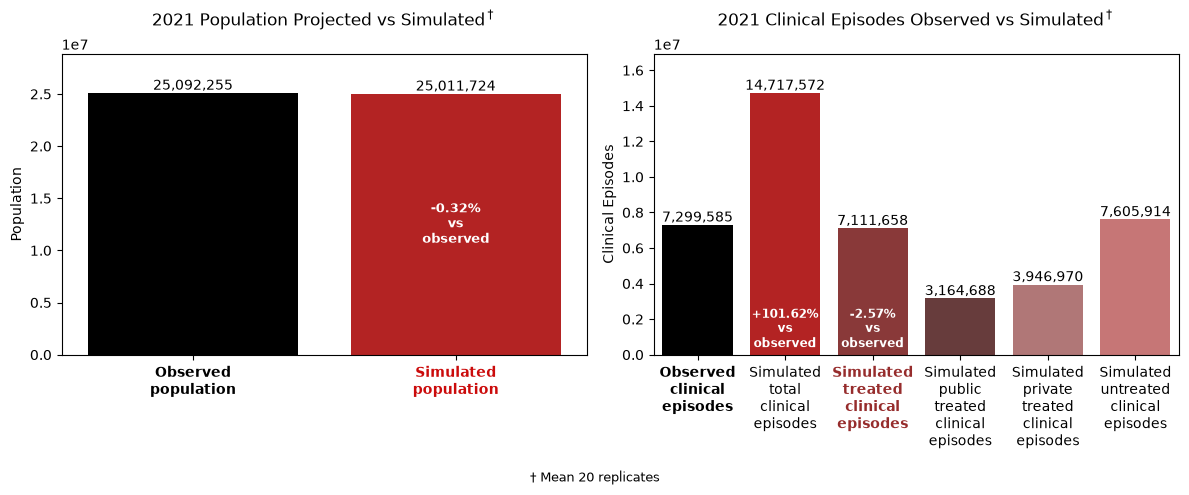

In [38]:
# Plot population and cases at calibration date and compare to raster and csv
# Plot difference between raster and sims, and between csv and sims and show percentage difference on the plot

fig,ax = plt.subplots(1,2, figsize=(12,5))

# Add titles and labels
ax[0].set_title(f"{incidence_comparison_year} Population Projected vs Simulated$^\dagger$", pad=20)
ax[0].set_ylabel("Population")
ax[1].set_title(f"{incidence_comparison_year} Clinical Episodes Observed vs Simulated$^\dagger$", pad=20)
ax[1].set_ylabel("Clinical Episodes")

# cases_palette = {
#     "Observed": "#0000FF",              # distinct color
#     "Simulated (Total)": "#FF6666",          
#     "Simulated (Treated)": "#FF0000",             # same color as total, but different label
#     "Simulated (Public)": "#CC0000",     
#     "Simulated (Private)": "#880000",
#     "Simulated (Untreated)": "#440000",
# }

# cases_palette = {
#     "Observed":               "#1A56DB",  # blue — categorically different from all simulated
#     "Simulated (Total)":      "#4D4D4D",  # neutral grey — it's the aggregate, not a "side"
#     "Simulated (Treated)":    "#E31A1C",  # red — anchor color for the treated branch
#     "Simulated (Public)":     "#FB9A99",  # light red — tint of Treated (its subset)
#     "Simulated (Private)":    "#99000D",  # dark red/maroon — shade of Treated (its subset)
#     "Simulated (Untreated)":  "#FF7F00",  # orange — distinct hue, sibling to Treated
# }

cases_palette = {
    "Observed":               "#000000",  # black, outside the family entirely

    "Simulated (Total)":      "#CB0B0B",  # hsl(0, 90%, 42%) — vivid anchor

    "Simulated (Treated)":    "#962C2C",  # hsl(0, 55%, 38%) — muted, dark half
    "Simulated (Untreated)":  "#D36969",  # hsl(0, 55%, 62%) — muted, light half

    "Simulated (Public)":     "#6E3535",  # hsl(0, 35%, 32%) — dusty, dark subset
    "Simulated (Private)":    "#B96E6E",  # hsl(0, 35%, 58%) — dusty, light subset
}

plot_pop = sns.barplot(
    x=["Observed population", "Simulated population"],
    y=[pop_from_csv, agg_population_data_at_calibration_mean],
    hue=["Observed", "Simulated (Total)"],
    palette=cases_palette,
    legend=False,
    ax=ax[0]
 )
    
plot_cases = sns.barplot(
    x=["Observed clinical episodes", "Simulated total clinical episodes", "Simulated treated clinical episodes", "Simulated public treated clinical episodes", "Simulated private treated clinical episodes", "Simulated untreated clinical episodes"],
    y=[observed_clinical_cases, agg_clinical_episodes_data_at_calibration_sum, agg_treatment_data_at_calibration_sum, agg_treatment_data_at_calibration_sum_public, agg_treatment_data_at_calibration_sum_private, agg_untreated_cases_at_calibration_sum],
    hue=["Observed", "Simulated (Total)", "Simulated (Treated)", "Simulated (Public)", "Simulated (Private)", "Simulated (Untreated)"],
    palette=cases_palette,
    legend=False,
    ax=ax[1]
 )

# Calculate percentage differences
pop_pct_diff = (agg_population_data_at_calibration_mean - pop_from_csv) / pop_from_csv * 100
cases_pct_diff_total = (agg_clinical_episodes_data_at_calibration_sum - observed_clinical_cases) / observed_clinical_cases * 100
cases_pct_diff_treated = (agg_treatment_data_at_calibration_sum - observed_clinical_cases) / observed_clinical_cases * 100

print(f"Length of ax[0].patches: {len(ax[0].patches)}")
print(f"Length of ax[1].patches: {len(ax[1].patches)}")

# Annotate bars with values and percentage differences
for i, (bar, val) in enumerate(zip(ax[0].patches, [pop_from_csv, agg_population_data_at_calibration_mean])):
    ax[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

# Add percentage difference annotation on the second bar (population)
# bar = ax[0].patches[1]
ax[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5,
           f'{pop_pct_diff:+.2f}%\nvs\nobserved', ha='center', va='center',
           fontsize=9, color='white', fontweight=600)

# Annotate treatment bars with values
treatment_values = [observed_clinical_cases, agg_clinical_episodes_data_at_calibration_sum, agg_treatment_data_at_calibration_sum, agg_treatment_data_at_calibration_sum_public, agg_treatment_data_at_calibration_sum_private, agg_untreated_cases_at_calibration_sum]
for bar, val in zip(ax[1].patches, treatment_values):
    ax[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

observed_bar_height = ax[1].patches[0].get_height()
# Add percentage difference annotations on treatment bars (relative to csv)
for i, (bar, pct) in enumerate(zip(ax[1].patches[1:], [cases_pct_diff_total, cases_pct_diff_treated])):
    label = f'{pct:+.2f}%\nvs\nobserved'
    ax[1].text(bar.get_x() + bar.get_width() / 2, 200_000,
               label, ha='center', va='bottom',
               fontsize=8.5, color='white', fontweight='demibold')  # Use 'semi-bold' for better visibility on dark background

wrap_width = 12  
ax[0].set_xticklabels([textwrap.fill(label.get_text(), wrap_width) for label in ax[0].get_xticklabels()])
ax[1].set_xticklabels([textwrap.fill(label.get_text(), wrap_width) for label in ax[1].get_xticklabels()])

label_colors_0 = {
    "Observed population": cases_palette["Observed"],
    "Simulated population": cases_palette["Simulated (Total)"],
}

label_colors_1 = {
    "Observed clinical episodes": cases_palette["Observed"],
    "Simulated treated clinical episodes": cases_palette["Simulated (Treated)"],
}

for label in ax[0].get_xticklabels():
    label_text = label.get_text().replace("\n", " ")
    if label_text in label_colors_0:
        label.set_color(label_colors_0[label_text])
        label.set_fontweight('bold')

for label in ax[1].get_xticklabels():
    label_text = label.get_text().replace("\n", " ")
    if label_text in label_colors_1:
        label.set_color(label_colors_1[label_text])
        label.set_fontweight('bold')

ax[0].margins(y=0.15)
ax[1].margins(y=0.15)
ax[0].tick_params(axis='x', labelrotation=0)
ax[1].tick_params(axis='x', labelrotation=0)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='center', va='bottom', fontsize=9)

plt.savefig(f"{analysis_path}/{incidence_comparison_year}_observed_vs_simulated_population_and_incidence.png", dpi=200)
plt.show()